# **<span style="color: #87CEEB;">Optimizers and Autoencoders Experiments</span>**



In [1]:
# ============ Necessary libraries have been imported for you aleadry =============
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split
%matplotlib inline
import kagglehub
import cv2
import random
'''
You may include more libraries, if you want to
'''

'\nYou may include more libraries, if you want to\n'

In [2]:
BATCH_SIZE = 16

<hr>

## <h1><b> Part 3: Medical Image Segmentation with U-Net</b></h1>  

<hr>

This task involves segmenting brain tumors from MRI scans using an autoencoder. The goal is to train a model that can accurately segment tumors, indicated by binary masks, from MRI images. Your model should be symmetrical, and input-output resolutions must remain consistent, achieved via appropriate padding.

### **Task 1: Dataset Prep**
- You'll be using `brain-tumor-segmentation` dataset (you can access it from [here](https://www.kaggle.com/datasets/nikhilroxtomar/brain-tumor-segmentation?resource=download))
- You may download it locally or use it's kaggle link. In either case, make sure you have an `image` and a `mask` directory containing the images and the masks respectively for the brain tumor.
- The dataset consists of `3065` PNGs with dimensions `512x512`.

In [3]:
## Uncomment below lines ONLY if you're using kaggle
brain_tumor_segmentation_path = kagglehub.dataset_download('nikhilroxtomar/brain-tumor-segmentation')
print(brain_tumor_segmentation_path)

dataset_base = "/root/.cache/kagglehub/datasets/nikhilroxtomar/brain-tumor-segmentation/versions"
print(os.listdir(dataset_base))

100%|██████████| 312M/312M [00:02<00:00, 145MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/nikhilroxtomar/brain-tumor-segmentation/versions/1
['1']


In [4]:
image_dir = "/root/.cache/kagglehub/datasets/nikhilroxtomar/brain-tumor-segmentation/versions/1/images"
mask_dir  = "/root/.cache/kagglehub/datasets/nikhilroxtomar/brain-tumor-segmentation/versions/1/masks"

img_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])
mask_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

def load_brain_tumor_dataset(image_dir, mask_dir, transform=None, mask_transform=None):
    image_filenames = sorted(os.listdir(image_dir))
    mask_filenames = sorted(os.listdir(mask_dir))

    images = []
    masks = []

    for img_file, mask_file in zip(image_filenames, mask_filenames):
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)

        image = Image.open(img_path).convert("L")
        mask  = Image.open(mask_path).convert("L")

        if transform:
            image = transform(image)
        if mask_transform:
            mask = mask_transform(mask)

        mask = (mask > 0.5).float()

        images.append(image)
        masks.append(mask)

    return images, masks


In [5]:
# Load images and ground truths
data = list()
ground_truths = list()

'''
1. Load all image files and the corresponding ground truth mask files from their respective directories.
2. Read the images and masks and apply pre-processing (if any).
3. Append the preprocessed images to the `data` list and the corresponding masks to the `ground_truths`
   list (both list have initialized above).

Make sure each image correctly corresponds to its mask.
'''
# ============ Your code here ============= #

images, masks = load_brain_tumor_dataset(image_dir, mask_dir, transform=img_transform, mask_transform=mask_transform)
print("Total images loaded:", len(images))

Total images loaded: 3064


In [6]:
'''
1. Create a train-val-test split using DataLoader (ideally 70% test, 20% val, and 10% test
   would be okay but upto you to come up with your own split composition).
2. You may use train_test_split() function (imported above) for splitting, but if you're
   comfortable with split strategies, that's totally fine.
3. Once splitted, use DataLoader class to load the datasets.
'''

dataset = list(zip(images, masks))
n = len(dataset)

train_len = int(0.7 * n)
val_len   = int(0.15 * n)
test_len  = n - train_len - val_len

random.shuffle(dataset)
train_dataset = dataset[:train_len]
val_dataset   = dataset[train_len:train_len+val_len]
test_dataset  = dataset[train_len+val_len:]

print(f"Train images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"train batches: {len(train_loader)*BATCH_SIZE} ({len(train_loader)/3065*BATCH_SIZE*100}%)")
print(f"val batches: {len(val_loader)*BATCH_SIZE} ({len(val_loader)/3065*BATCH_SIZE*100}%)")
print(f"test batches: {len(test_loader)} ({len(test_loader)/3065*100}%)")

# you may define your own variable names for loaders (names used above are just samples)

Train images: 2144
Validation images: 459
Test images: 461
train batches: 2144 (69.9510603588907%)
val batches: 464 (15.138662316476346%)
test batches: 29 (0.9461663947797716%)


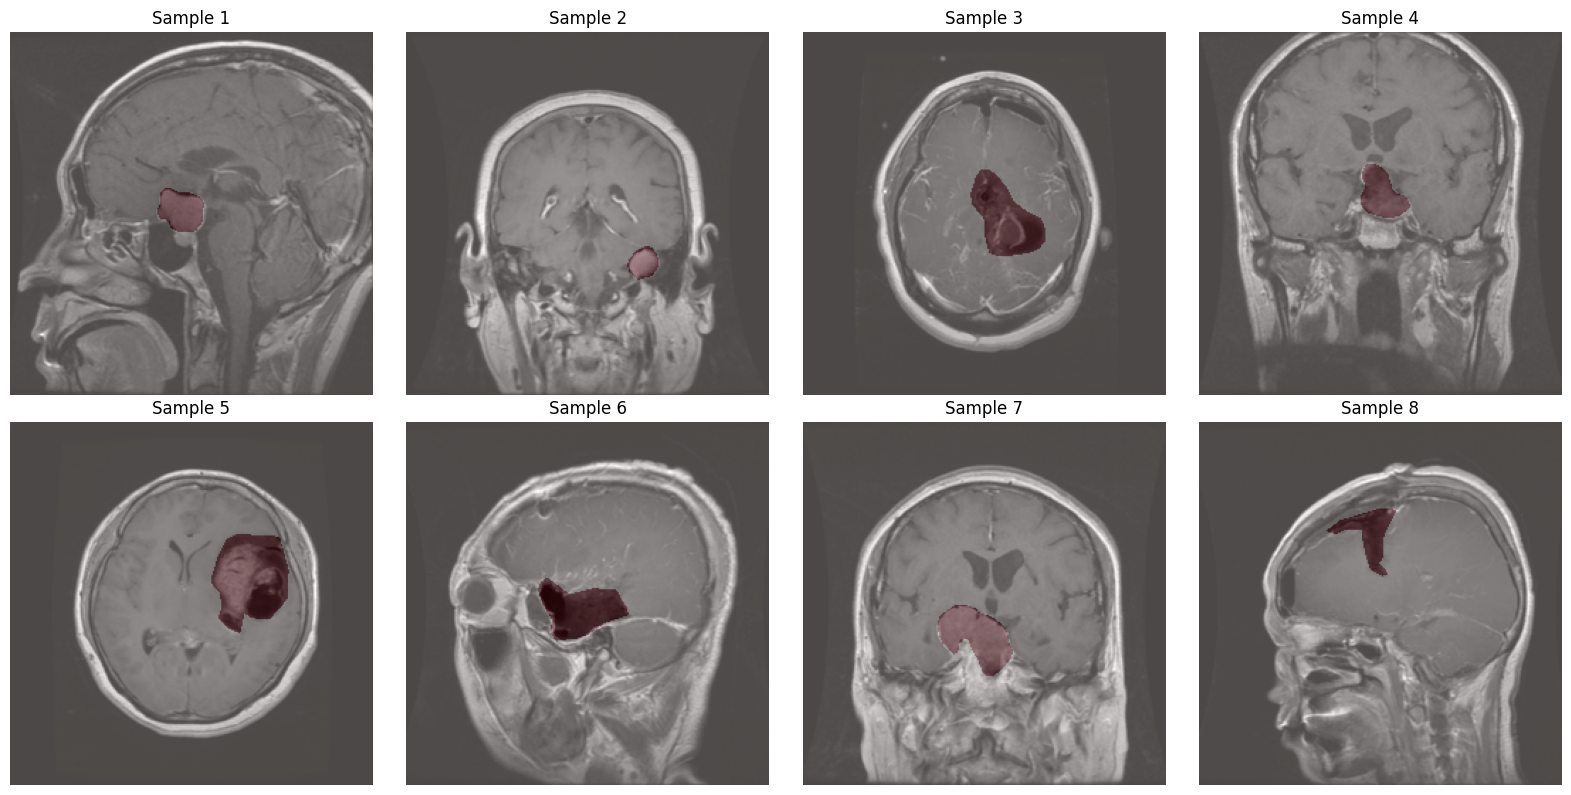

In [7]:
'''
Once you're done making the dataset, use the function below to vizualize it.
'''
def visualize_samples(images, masks):
    num_samples = len(images)
    fig, axes = plt.subplots(nrows=2, ncols=num_samples // 2, figsize=(16, 8))

    for i, (image, mask) in enumerate(zip(images, masks)):
        image = image.squeeze(0)
        mask = mask.squeeze(0)
        ax = axes[i // (num_samples // 2), i % (num_samples // 2)]
        ax.imshow(image, cmap='gray')
        ax.imshow(mask, alpha=0.3, cmap='Reds')
        ax.axis('off')
        ax.set_title(f'Sample {i+1}')
    plt.tight_layout()
    plt.show()


# Select 8 random samples from the training dataset
random_indices = np.random.choice(len(train_dataset), 8, replace=False)
random_samples = [(train_dataset[i][0], train_dataset[i][1]) for i in random_indices]

# Separate images and masks
random_images = [sample[0] for sample in random_samples]
random_masks = [sample[1] for sample in random_samples]

visualize_samples(random_images, random_masks)


### **Task 2: Implement the Dice Loss Function**  
In segmentation tasks, using MSE loss is often ineffective due to class imbalance, especially when the region of interest (e.g., brain tumors) is small. Hence, you are going to implement the Dice Loss by creating a custom `DiceLoss` class. Dice Loss is more suitable for segmentation tasks as it directly measures overlap between predictions and ground truth.  

Given:  
- **Predicted mask:** \( p \)  
- **Ground truth:** \( t \)  
- **Smoothing factor:** \( s \) (prevents division by zero)  

#### $L = 1 - \frac{2 \cdot \sum(p \cdot t) + s}{\sum(p^{2}) + \sum(t^{2}) + s}$

The smoothing factor $s$ is a small value (usually of the order of $1e^{-6}$).
For more details, see [this paper](https://arxiv.org/pdf/1606.04797.pdf) (page 6).  


In [8]:
class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()
        self.dbz = 1e-6


    def forward(self, prediction, target):
        prediction = prediction.contiguous().view(-1)
        target = target.contiguous().view(-1)

        intersection = (prediction * target).sum()
        dice = (2. * intersection + self.dbz) / (prediction.pow(2).sum() + target.pow(2).sum() + self.dbz)
        loss = 1 - dice
        return loss

### **Task 3: Define Autoencoder for Brain Tumor segmentation**


In [15]:
class SegmentationAE(nn.Module):
    def __init__(self):
        super(SegmentationAE, self).__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()  )

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        d4 = self.dec4(x4)
        d3 = self.dec3(d4)
        d2 = self.dec2(d3)
        out = self.dec1(d2)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SegmentationAE().to(device)
summary(model, input_size=(1, 256, 256), batch_size=BATCH_SIZE)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [16, 32, 256, 256]             320
       BatchNorm2d-2         [16, 32, 256, 256]              64
              ReLU-3         [16, 32, 256, 256]               0
            Conv2d-4         [16, 32, 256, 256]           9,248
       BatchNorm2d-5         [16, 32, 256, 256]              64
              ReLU-6         [16, 32, 256, 256]               0
         MaxPool2d-7         [16, 32, 128, 128]               0
            Conv2d-8         [16, 64, 128, 128]          18,496
       BatchNorm2d-9         [16, 64, 128, 128]             128
             ReLU-10         [16, 64, 128, 128]               0
           Conv2d-11         [16, 64, 128, 128]          36,928
      BatchNorm2d-12         [16, 64, 128, 128]             128
             ReLU-13         [16, 64, 128, 128]               0
        MaxPool2d-14           [16, 64,

### **Task 4: Define the Training Loop**  

- Print both the training and validation losses for each epoch.  
- Plot the training and validation loss curves, with epochs on the x-axis and losses on the y-axis, at the end of the training.  
- Save the best model as a `.pth` file using the `torch.save()` method.   
- After every 2ish epochs, visualize a grid displaying the Image | Ground Truth Mask | Predicted Mask.


Epoch [1/20], Train Loss: 0.7927, Val Loss: 0.6397
Best model saved!
Epoch [2/20], Train Loss: 0.3914, Val Loss: 0.3669
Best model saved!


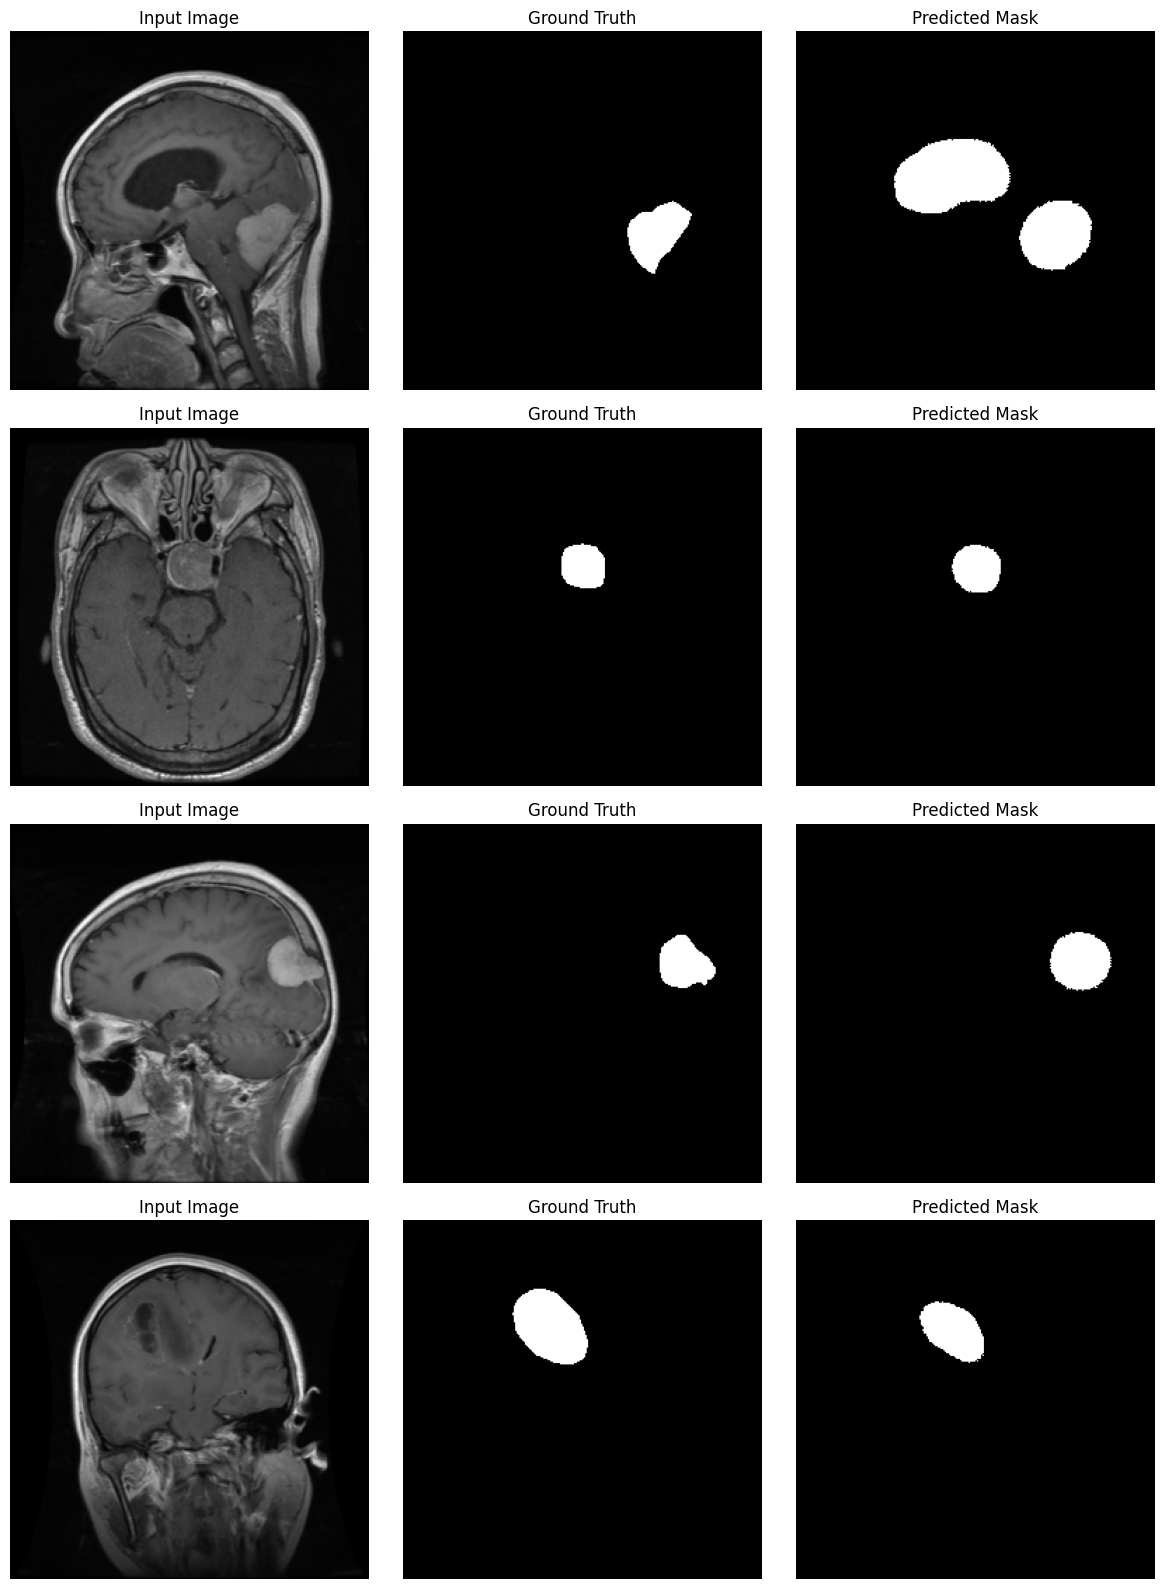

Epoch [3/20], Train Loss: 0.2843, Val Loss: 0.3911
Epoch [4/20], Train Loss: 0.2346, Val Loss: 0.2843
Best model saved!


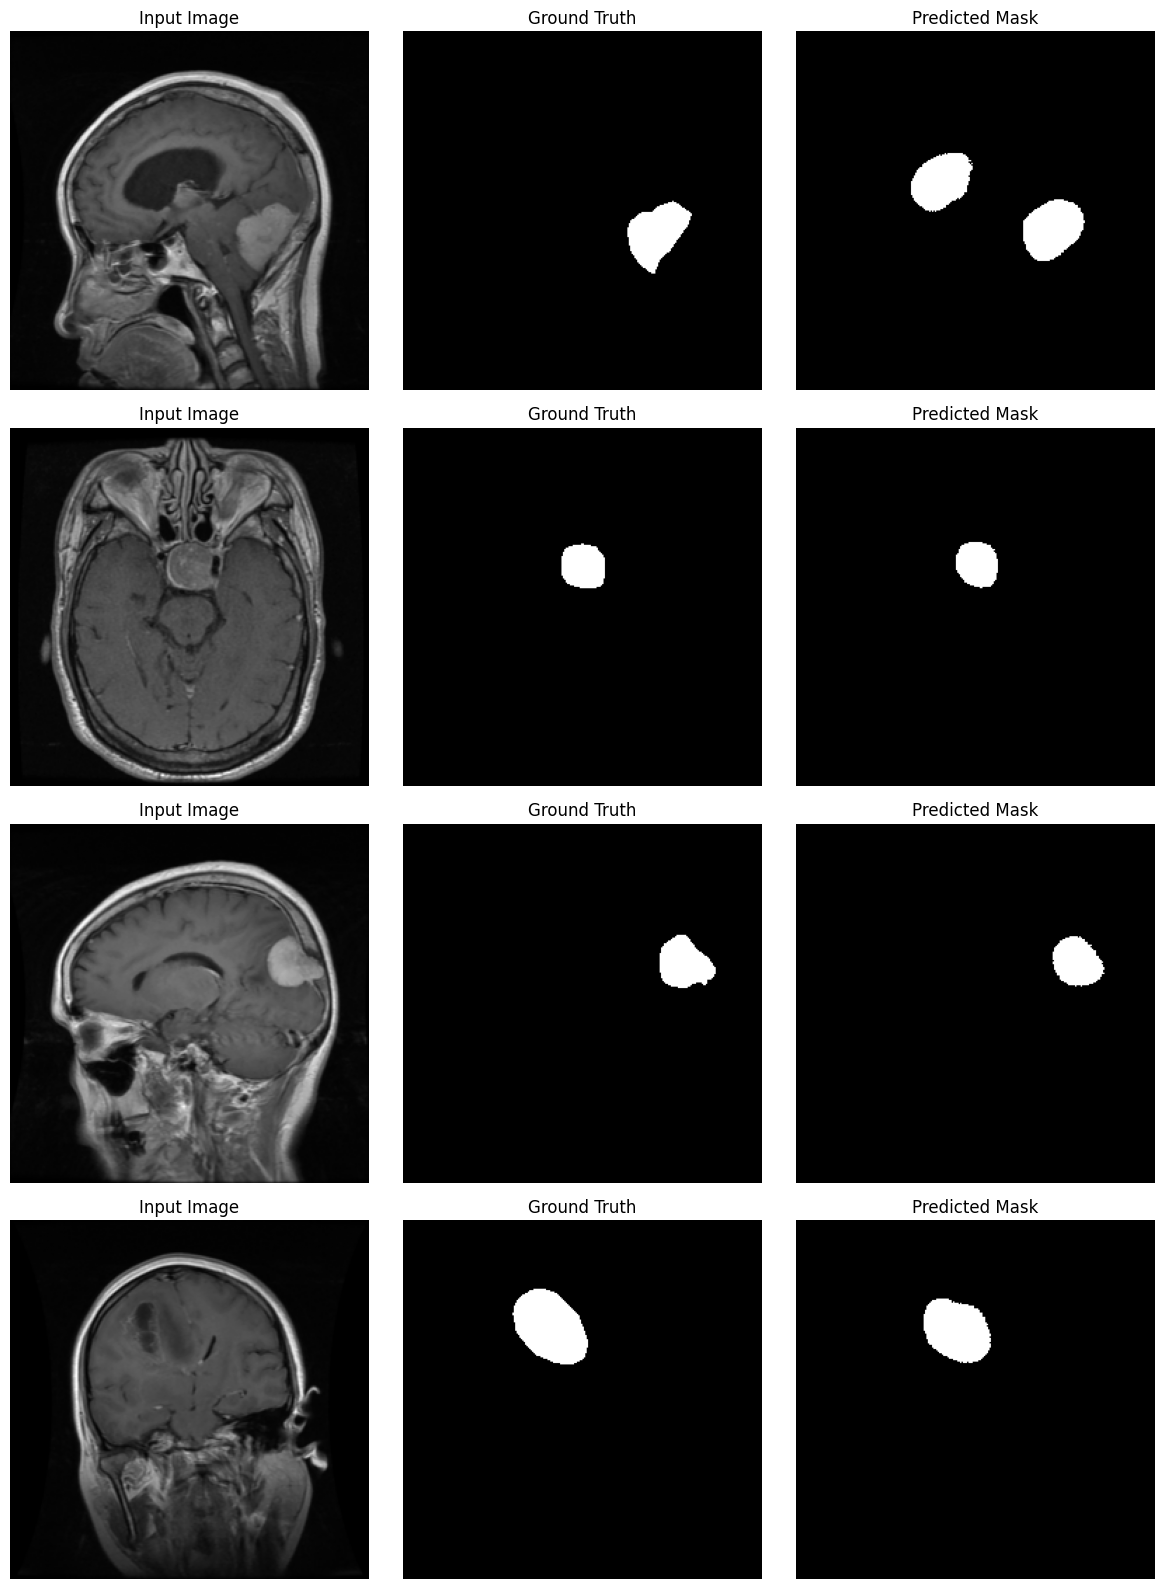

Epoch [5/20], Train Loss: 0.2021, Val Loss: 0.2327
Best model saved!
Epoch [6/20], Train Loss: 0.1778, Val Loss: 0.2451


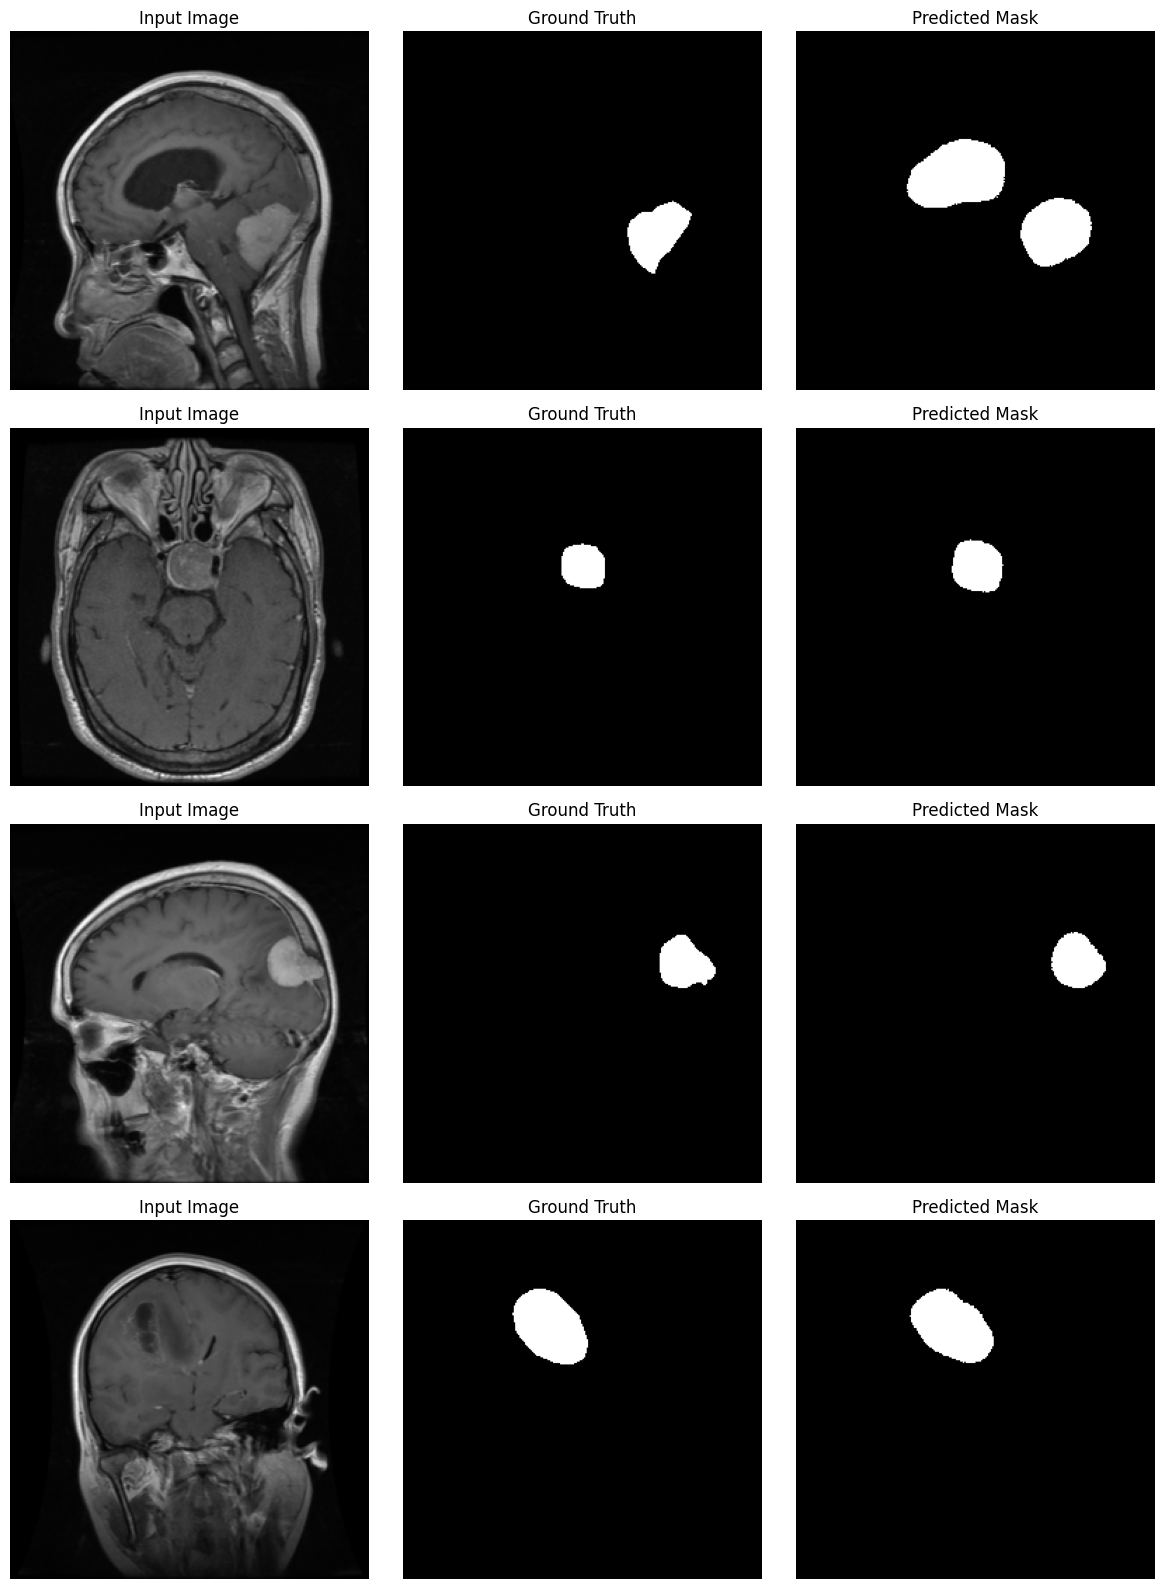

Epoch [7/20], Train Loss: 0.1581, Val Loss: 0.2299
Best model saved!
Epoch [8/20], Train Loss: 0.1402, Val Loss: 0.2359


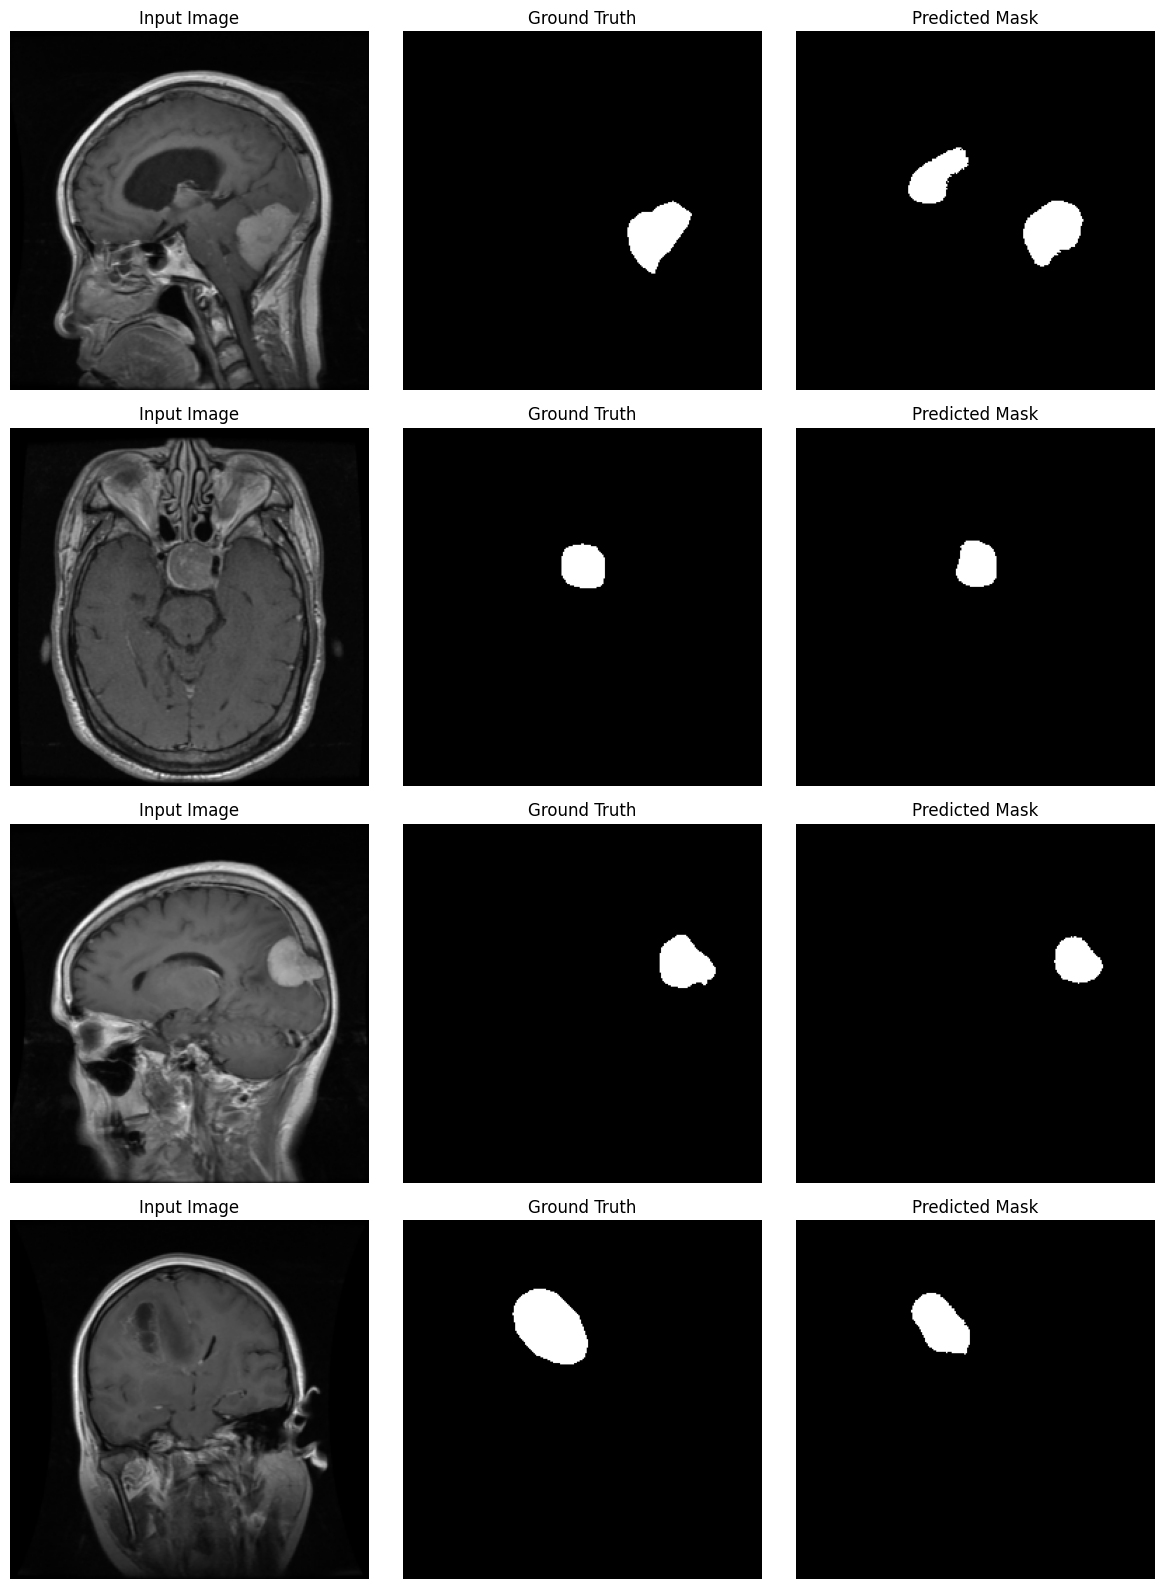

Epoch [9/20], Train Loss: 0.1228, Val Loss: 0.2350
Epoch [10/20], Train Loss: 0.1077, Val Loss: 0.2079
Best model saved!


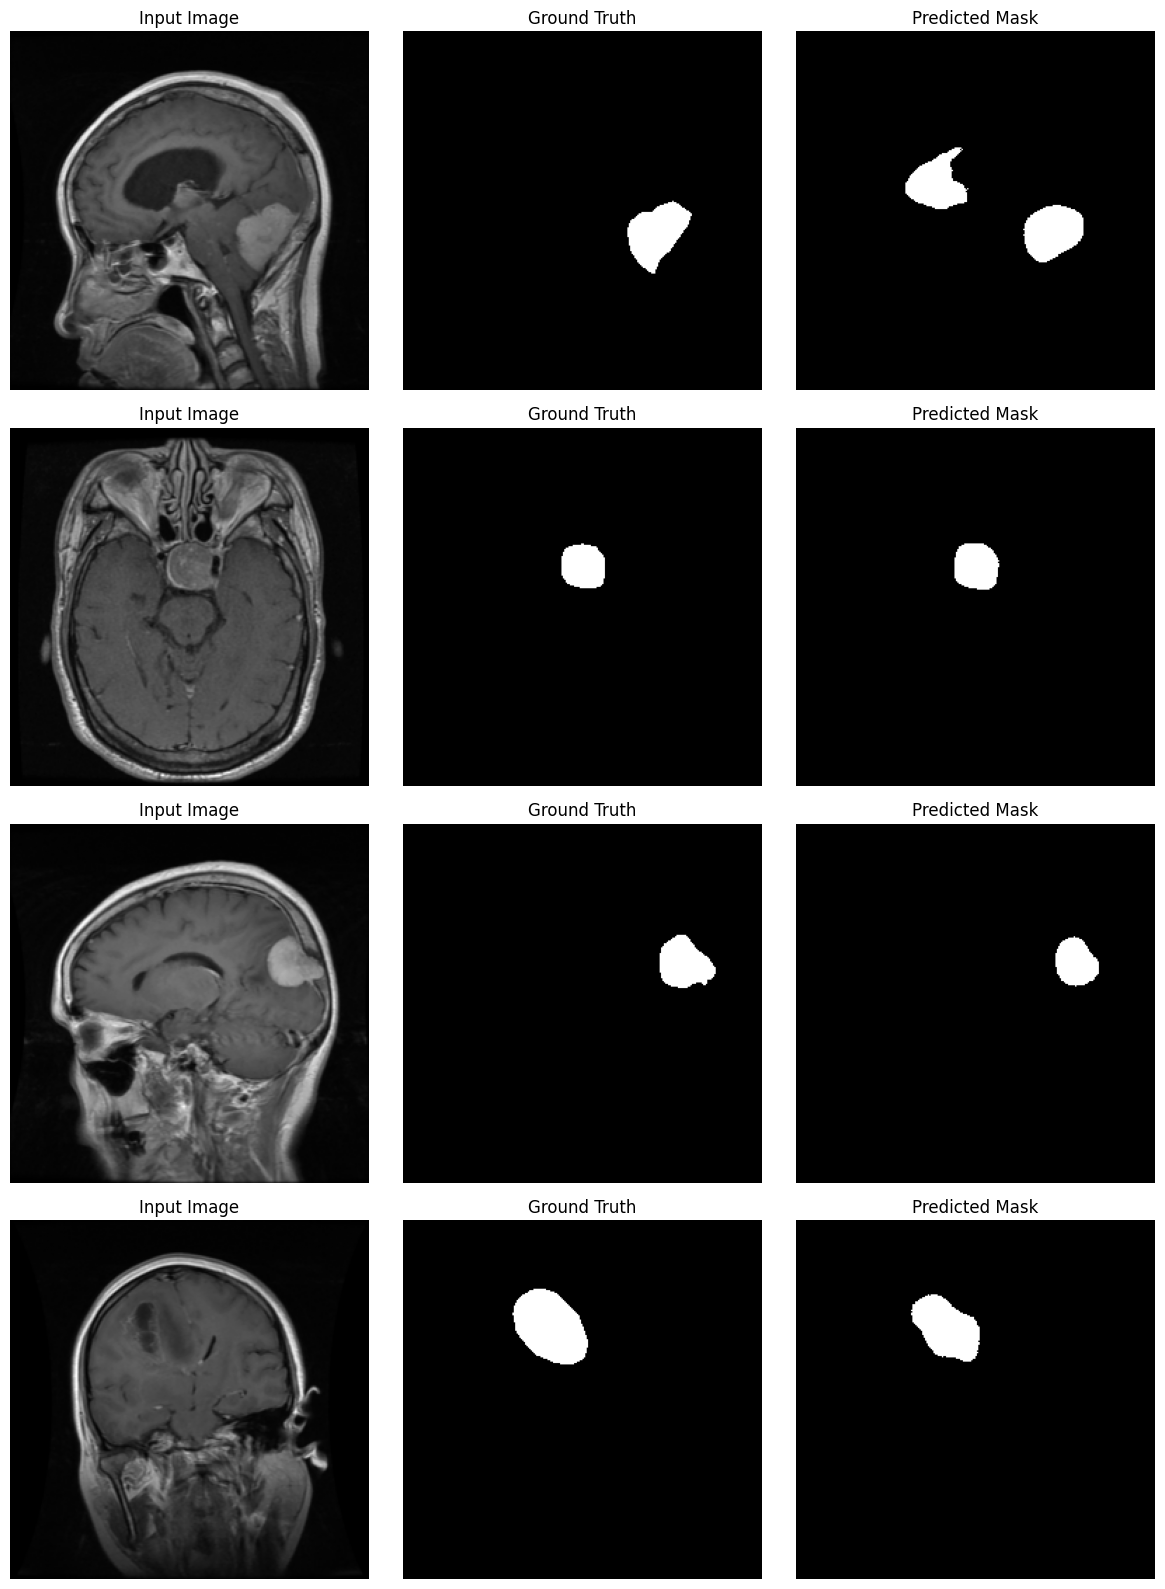

Epoch [11/20], Train Loss: 0.1045, Val Loss: 0.1973
Best model saved!
Epoch [12/20], Train Loss: 0.0898, Val Loss: 0.2161


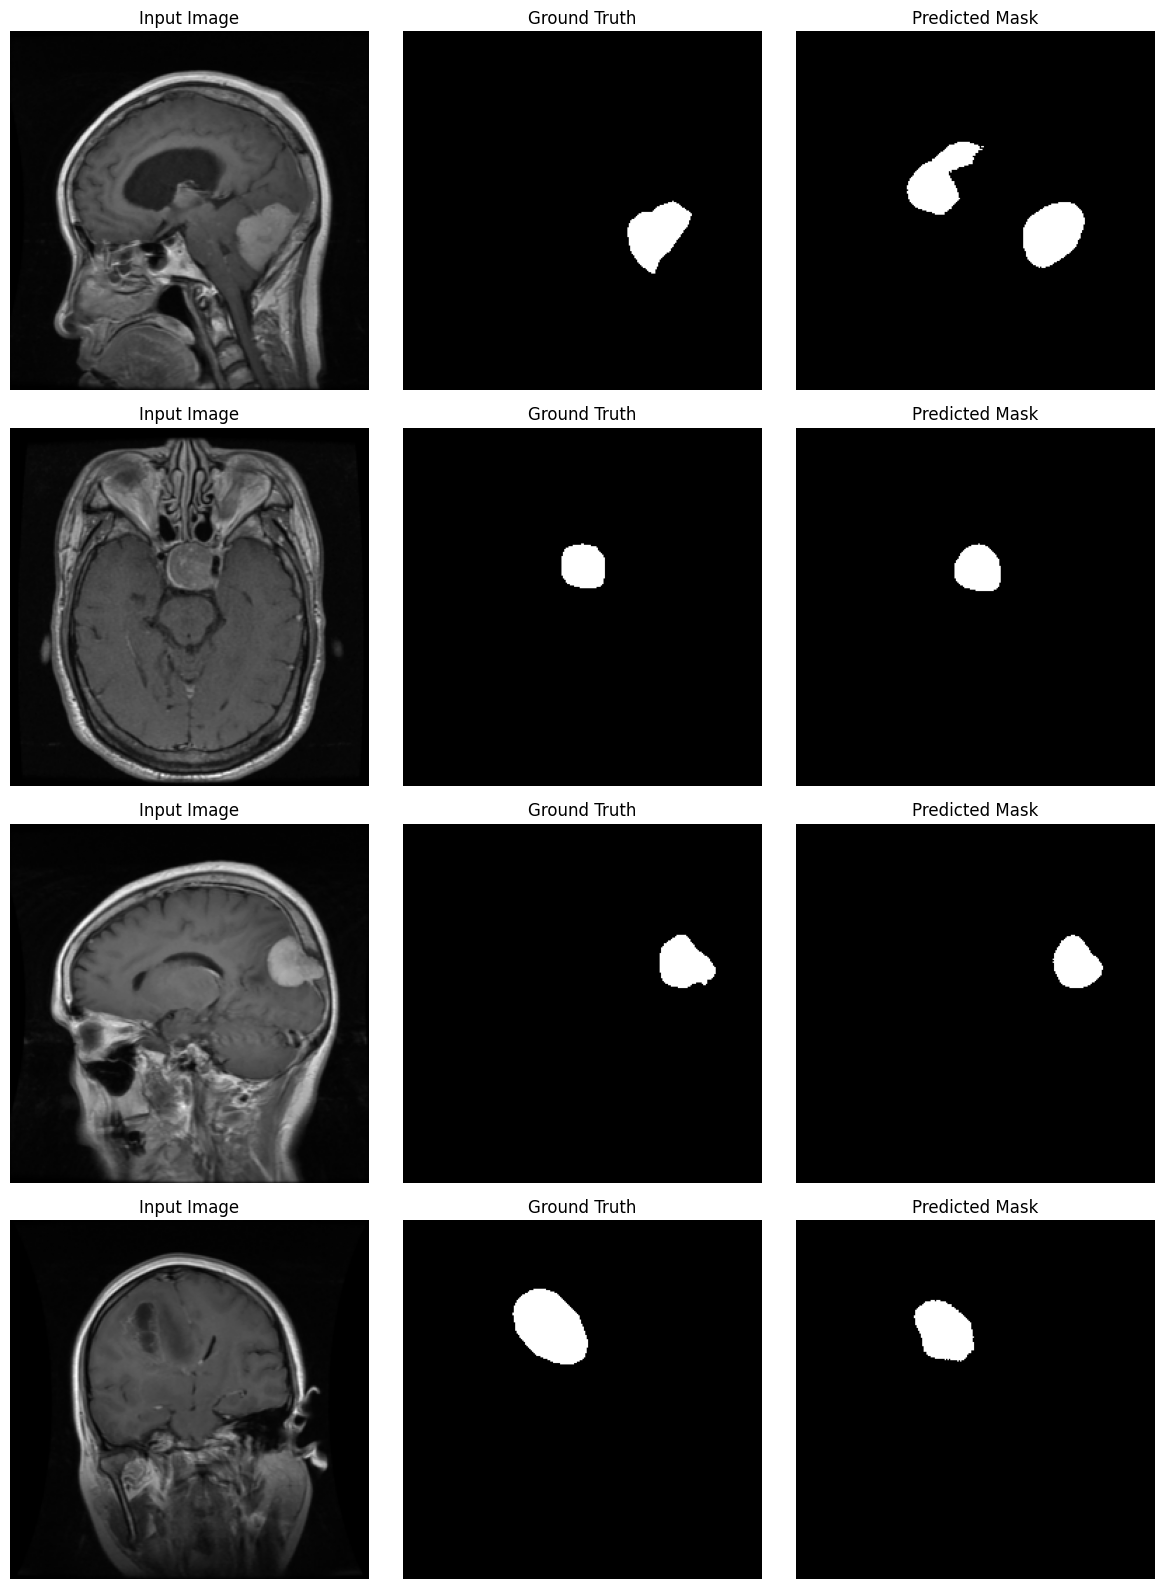

Epoch [13/20], Train Loss: 0.0761, Val Loss: 0.2134
Epoch [14/20], Train Loss: 0.0712, Val Loss: 0.1818
Best model saved!


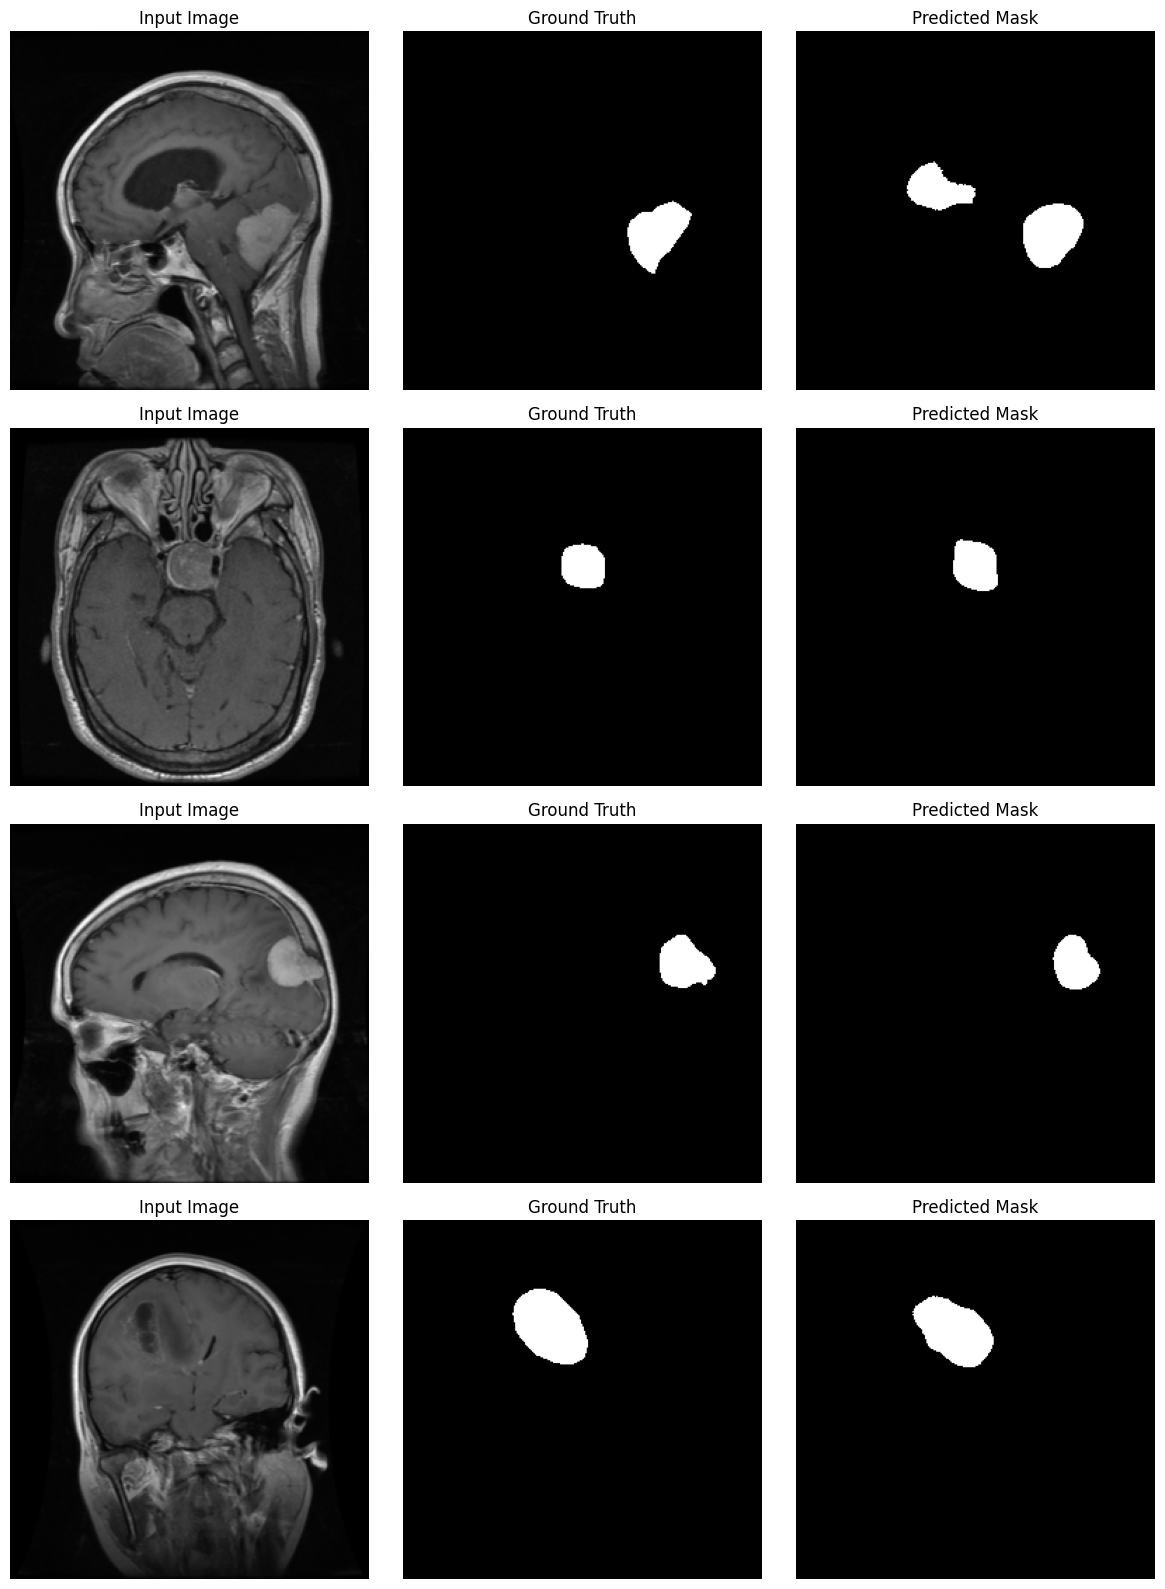

Epoch [15/20], Train Loss: 0.0636, Val Loss: 0.1958
Epoch [16/20], Train Loss: 0.0663, Val Loss: 0.2438


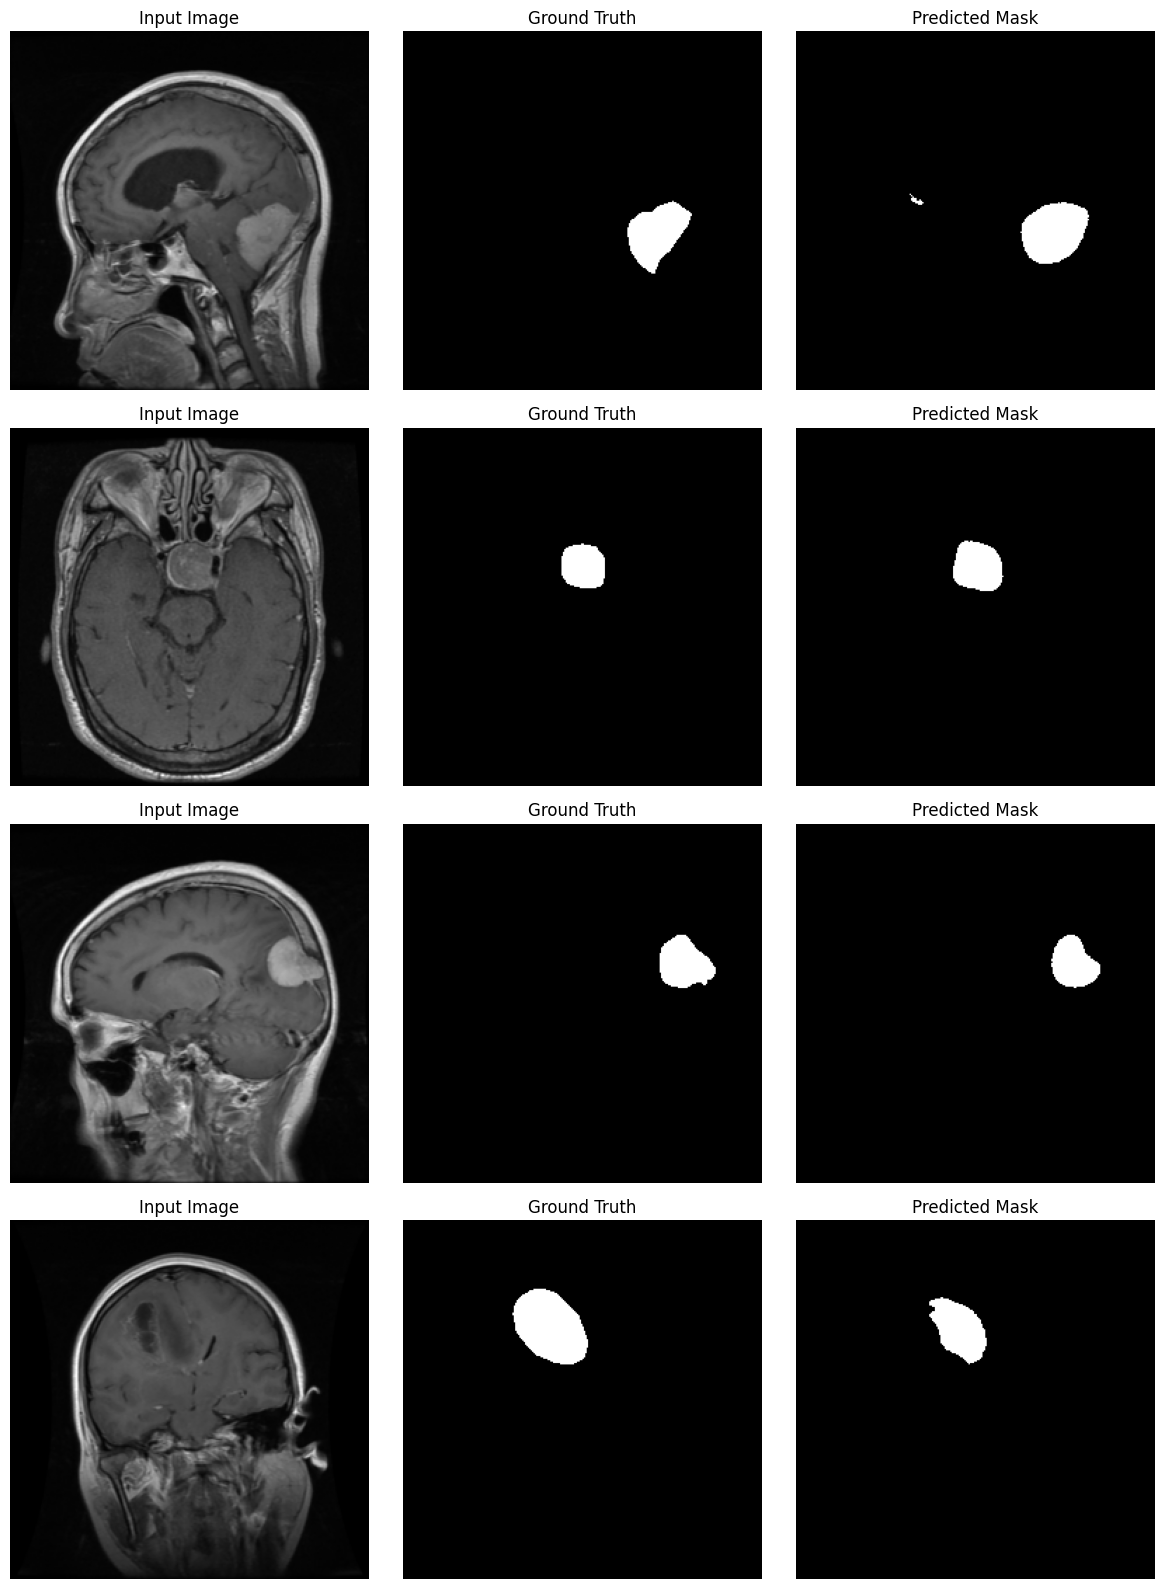

Epoch [17/20], Train Loss: 0.0598, Val Loss: 0.1915
Epoch [18/20], Train Loss: 0.0504, Val Loss: 0.2006


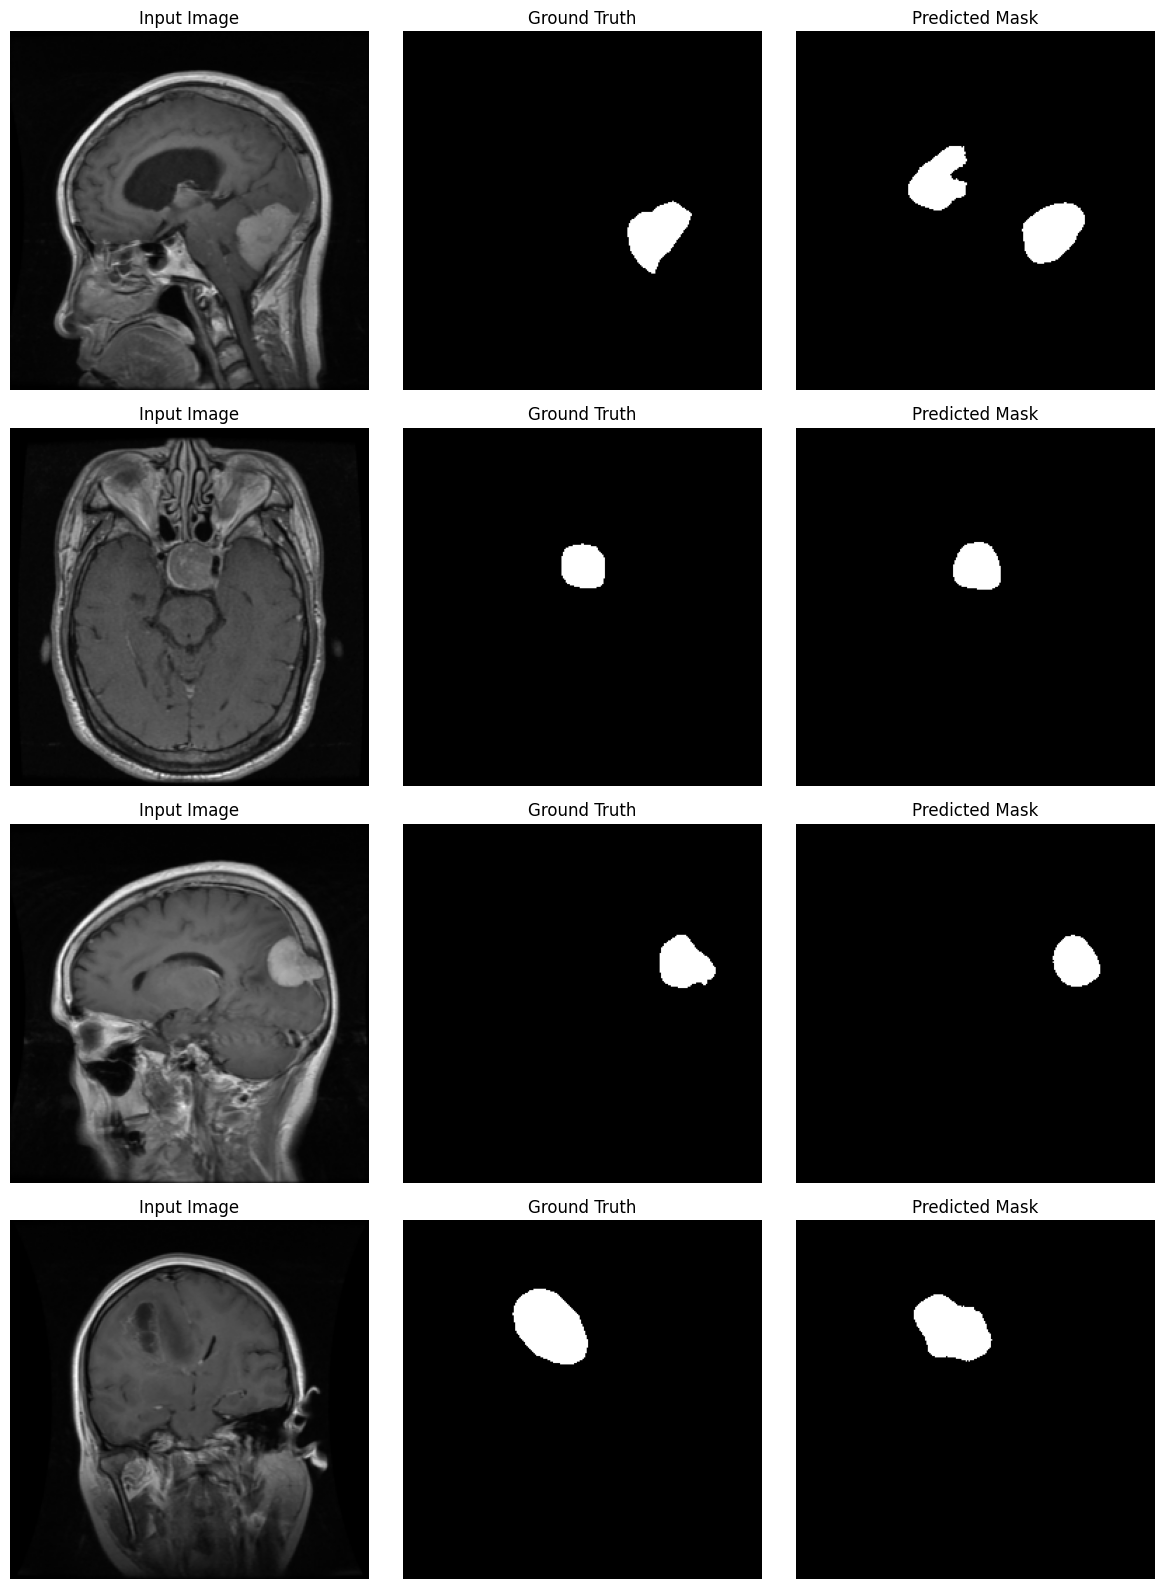

Epoch [19/20], Train Loss: 0.0464, Val Loss: 0.1851
Epoch [20/20], Train Loss: 0.0426, Val Loss: 0.1800
Best model saved!


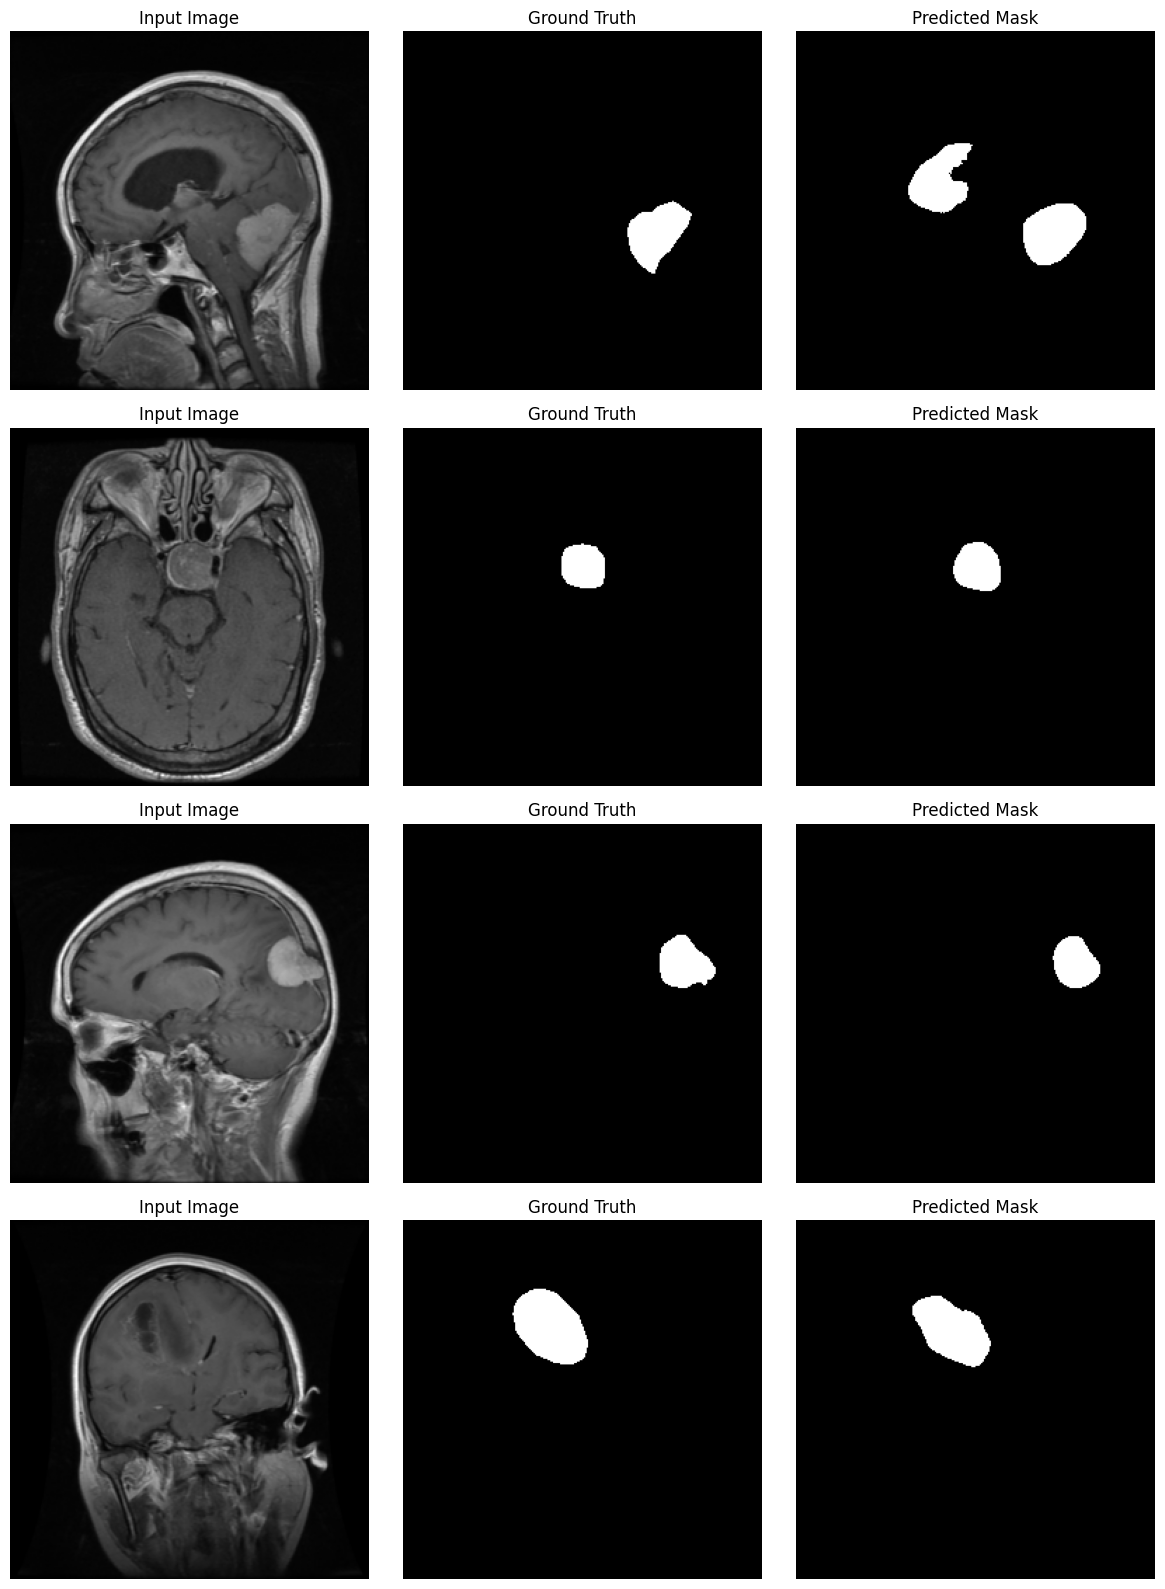

In [17]:
# ----------------------------
# 1. Setup: define criterion, optimizer, and number of epochs
# ----------------------------
criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 20
# ============ Your code here ============= #

def visualize_prediction(images, masks, preds, num_samples=4):
    images = images.cpu().detach().numpy()
    masks = masks.cpu().detach().numpy()
    preds = preds.cpu().detach().numpy()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    for i in range(num_samples):

        axes[i, 0].imshow(images[i].squeeze(), cmap='gray')
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(preds[i].squeeze(), cmap='gray')
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis("off")
    plt.tight_layout()
    plt.show()

best_val_loss = float('inf')
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "ahem3.pth")
        print("Best model saved!")

    if (epoch + 1) % 2 == 0:
        model.eval()
        images, masks = next(iter(val_loader))
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = (outputs > 0.5).float()
        visualize_prediction(images, masks, preds, num_samples=min(4, images.size(0)))


### **Task 5: Evaluate Your Autoencoder's Segmentation**  

- Select and visualize **10 random samples** from the test set, displaying the **Image | Ground Truth Mask | Predicted Mask** in a grid format.  
- Compute the **Dice Coefficient** and **Intersection over Union (IoU)** scores for the entire test dataset.  

#### **Mathematical Expressions:**  
- **Dice Coefficient (DICE):**  $\text{DICE} = \frac{2 \times \sum(p \cup t)}{\sum(p) + \sum(t)}$

- **Intersection over Union (IoU):**  $\text{IoU} = \frac{\sum(p \cup t)}{\sum(p \cap t)}$

Where:  
- $p$ = Predicted mask (binary)  
- $t$ = Ground truth mask (binary)  

Make sure to print the computed scores.

In [18]:
def dice_coef(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask * groundtruth_mask)
    total_sum = np.sum(pred_mask) + np.sum(groundtruth_mask)
    dice = (2 * intersect) / total_sum if total_sum > 0 else 1.0
    return dice

def iou(groundtruth_mask, pred_mask):
    intersect = np.sum(pred_mask * groundtruth_mask)
    union = np.sum(pred_mask) + np.sum(groundtruth_mask) - intersect
    iou_value = intersect / union if union > 0 else 1.0
    return iou_value

Average Dice Coefficient on test set: 0.7266689517350822
Average IoU on test set: 0.6310440773303962


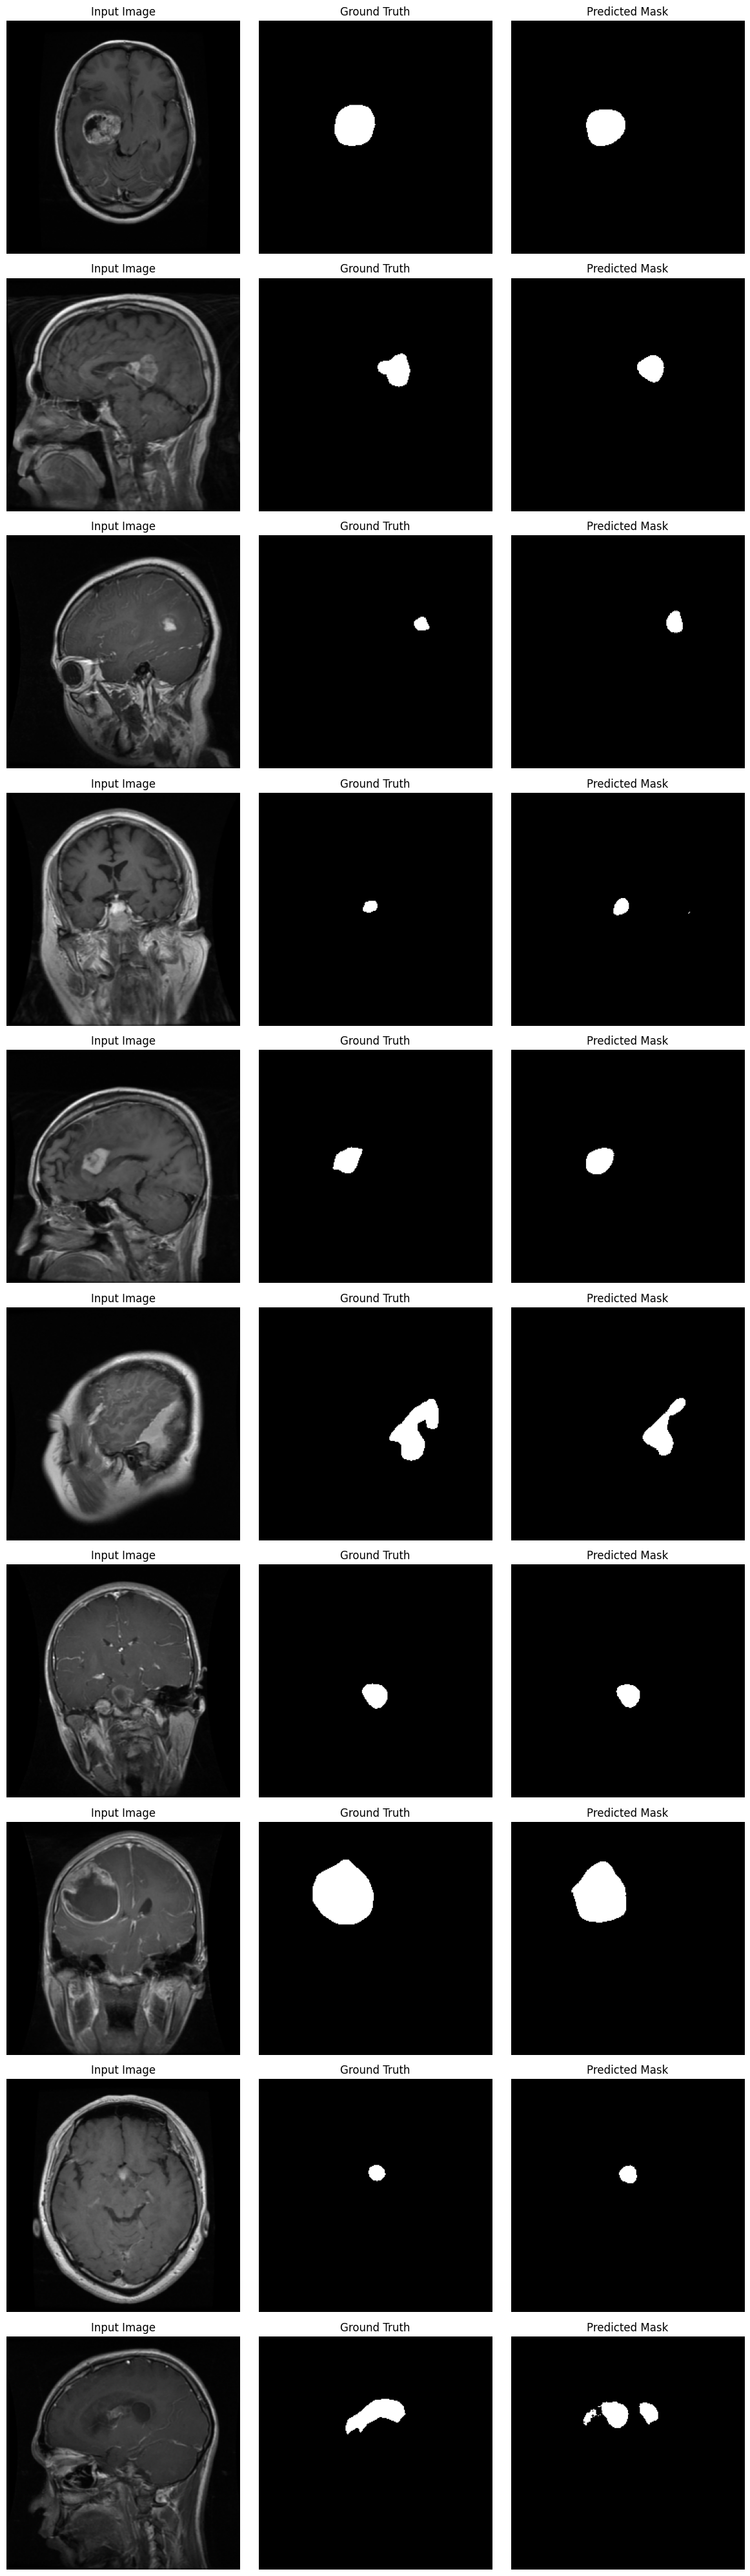

In [19]:
## Your code here
model.eval()
total_dice = 0.0
total_iou = 0.0
count = 0
all_images = []
all_masks = []
all_preds = []

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        outputs_bin = (outputs > 0.5).float()
        for i in range(images.size(0)):
            gt = masks[i].cpu().numpy()
            pred = outputs_bin[i].cpu().numpy()
            total_dice += dice_coef(gt, pred)
            total_iou  += iou(gt, pred)
            count += 1
            all_images.append(images[i].cpu())
            all_masks.append(masks[i].cpu())
            all_preds.append(outputs_bin[i].cpu())

avg_dice = total_dice / count
avg_iou  = total_iou / count

print("Average Dice Coefficient on test set:", avg_dice)
print("Average IoU on test set:", avg_iou)

indices = random.sample(range(len(all_images)), 10)
sample_images = [all_images[i] for i in indices]
sample_masks  = [all_masks[i] for i in indices]
sample_preds  = [all_preds[i] for i in indices]

def visualize_prediction_grid(images, masks, preds):
    num_samples = len(images)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    for i in range(num_samples):
        axes[i, 0].imshow(images[i].squeeze(), cmap='gray')
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")
        axes[i, 2].imshow(preds[i].squeeze(), cmap='gray')
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis("off")
    plt.tight_layout()
    plt.show()

visualize_prediction_grid(sample_images, sample_masks, sample_preds)

## Experiments
- Notebook.